In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Read my dataset
df=pd.read_excel("amazon_sales.xlsx")

In [5]:
# Display
# Number of columns and rows
df.shape

(100000, 20)

In [6]:
# Column names
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [7]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [8]:
# Statistical summary of numerical columns
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [9]:
# KPI analysis
# Total sales
df['TotalAmount'].sum()

np.float64(91825647.92)

In [10]:
# Total orders
df['OrderID'].count()

np.int64(100000)

In [11]:
# average sales
df['TotalAmount'].mean()

np.float64(918.2564792000001)

In [13]:
# Maximum sales
df['TotalAmount'].max()

3534.98

In [14]:
# Minimum sales
df['TotalAmount'].min()

4.27

In [15]:
# Sales Analysis
# Revenue by state
df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [49]:
# Revenue by category
df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

,TotalAmount
Category,
Electronics,15584217.18
Sports & Outdoors,15345571.88
Books,15261837.01
Clothing,15253397.50
Toys & Games,15216684.99
Home & Kitchen,15163939.36


In [16]:
# Customer and Product analysis
# Top 5 customers
df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head()

,TotalAmount
CustomerID,
CUST023748,15215.79
CUST009614,12160.96
CUST034178,11418.88
CUST001153,11282.96
CUST004883,11214.44


In [51]:
# Top 10 products based on sales
df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)

,TotalAmount
ProductName,
Memory Card 128GB,1935138.40
LED Desk Lamp,1921948.41
Mechanical Keyboard,1906963.54
Electric Kettle,1905751.79
Smartwatch,1901275.59
Dress Shirt,1896765.36
Water Bottle,1895467.95
Gaming Mouse,1895103.98
Kids Toy Car,1891082.43


In [19]:
# Total quantity sold
df.groupby('ProductName')['Quantity'].sum()

,Quantity
ProductName,
4K Monitor,6111
Action Camera,6104
Air Fryer,5956
Backpack,5848
Bluetooth Speaker,5782
Board Game,6200
Car Charger,5754
Children's Book,5619
Cookware Set,6130


In [53]:
# Number of orders places using each payment mode
# Orders by payment method
df.groupby('PaymentMethod')['OrderID'].count().sort_values(ascending=False)

,OrderID
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


In [55]:
# Time based analysis
#df.groupby('OrderDate')['TotalAmount'].sum()
df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum()

,TotalAmount
OrderDate,
2020-01,1637069.40
2020-02,1339388.21
2020-03,1587125.66
2020-04,1588347.29
2020-05,1533834.17
2020-06,1500269.29
2020-07,1552981.94
2020-08,1640874.93
2020-09,1554682.21


In [56]:
# The month with highest sales
print(monthly_sales.idxmax())
print(monthly_sales.max())

(np.int32(2024), 'May')
1642609.94


In [23]:
# Multi-level analysis
df.groupby(['State','Category'])['TotalAmount'].sum()

State  Category         
AZ     Books                793211.33
       Clothing             691249.82
       Electronics          747955.37
       Home & Kitchen       737616.34
       Sports & Outdoors    694318.06
                              ...    
WA     Clothing             747668.70
       Electronics          879580.90
       Home & Kitchen       809448.28
       Sports & Outdoors    807282.60
       Toys & Games         711514.12
Name: TotalAmount, Length: 78, dtype: float64

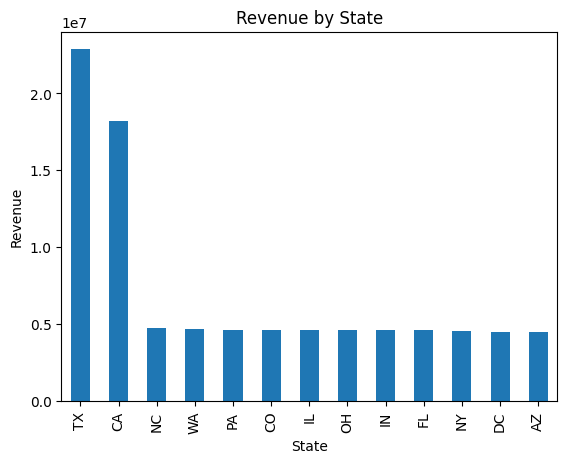

In [26]:
# Visualization
# Revenue by state
df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.show()

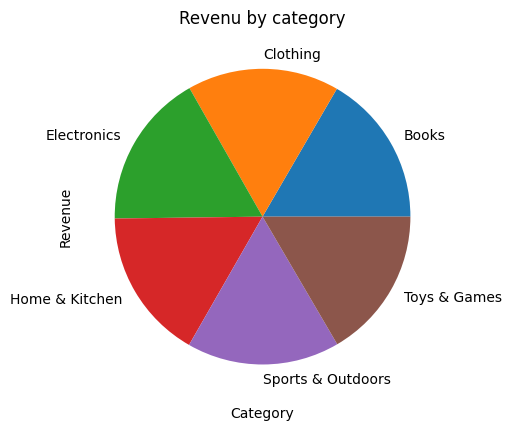

In [31]:
# Revenue by category
df.groupby('Category')['TotalAmount'].sum().plot(kind='pie')
plt.title('Revenu by category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

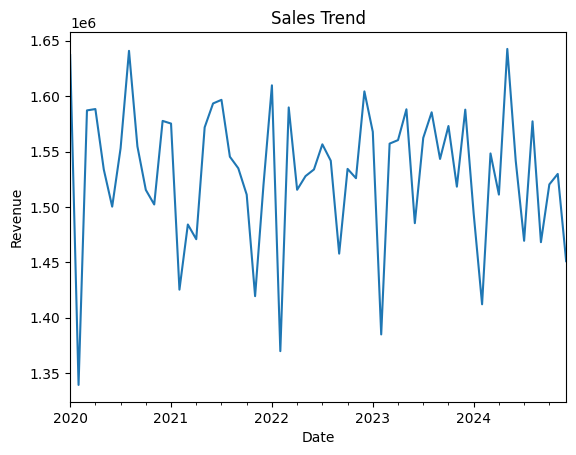

In [45]:
# Sales trend
df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum().plot(kind='line')
plt.title('Sales Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

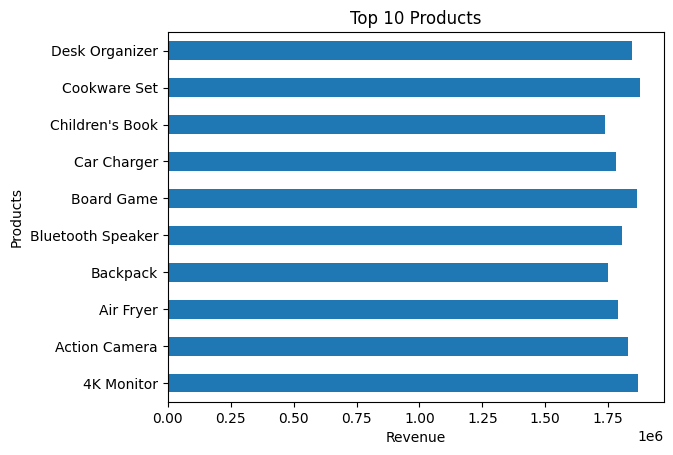

In [39]:
# Top 10 products
df.groupby('ProductName')['TotalAmount'].sum().head(10).plot(kind='barh')
plt.title('Top 10 Products')
plt.xlabel('Revenue')
plt.ylabel('Products')
plt.show()

In [ ]:
# Ans1. Total sales=91825647.92 , Average order value=918.2564792000001
# Ans2. The state with highest sales is TX (22862540.54)
#       The state with lowest sales is AZ	(4504324.19)
# Ans3. The category with the highest revenue is Electronics	(15584217.18)
# Ans4. The top10 products are Memory Card 128GB	1935138.40
#                              LED Desk Lamp	1921948.41
#                              Mechanical Keyboard	1906963.54
#                              Electric Kettle	1905751.79
#                              Smartwatch	1901275.59
#                              Dress Shirt	1896765.36
#                              Water Bottle	1895467.95
#                              Gaming Mouse	1895103.98
#                              Kids Toy Car	1891082.43
#                              Jeans	1882591.82
# Ans5. The top 5 customers are CUST023748	15215.79
#                               CUST009614	12160.96
#                               CUST034178	11418.88
#                               CUST001153	11282.96
#                               CUST004883	11214.44
# Ans6. The most preferred payment mode is Credit Card	35038
# Ans7. The month with highest sales is May 2024 (1642609.94)
#         The monthly sales trend shows that revenue remained relatively stable
#         throughout the period from 2020 to 2024. Sales fluctuated between
#         approximately 1.34 million and 1.64 million, with several peaks and
#         dips, but there was no sustained increase or decrease over time. This
#         indicates consistent business performance with normal month-to-month
#         variations.
# Ans8. Products or categories with high sales may still generate low profits if
#       they receive high discounts or incur high shipping costs. Therefore,
#       management should monitor discount policies and logistics costs to ensure
#       that strong sales also translate into higher profitability.
# Ans9. The state that requires improvement in salses performance is AZ	(4504324.19)
#       The state with the lowest sales performance requires targeted business
#       interventions to improve revenue. Recommended strategies include
#       increasing marketing efforts, offering promotional discounts, ensuring
#       product availability, improving customer service, and analyzing customer
#       preferences. Implementing these strategies can help increase customer
#       engagement and drive sales growth in the underperforming region.
# Ans10. Based on the sales analysis, Amazon should focus on improving sales in
#        underperforming regions such as Arizona, invest more in high-revenue
#        categories like Electronics, and use historical sales trends to
#        optimize marketing, inventory, and operational planning. These
#        strategies are expected to increase sales, improve customer
#        satisfaction, and enhance overall profitability.